<div align="center">

# **DASC-6010 Project**  
## **Bitcoin Price Effect on Altcoins**  
### **Group AnAyltics**

</div>

# 1. Connect to Database & Load the Data

In [1]:
import pandas as pd
import numpy as np
import sqlalchemy
from sqlalchemy import create_engine

username = 'postgres'
password = 'postgres'
host     = 'localhost'     
port     = '9432'           
database = 'anayltics'

engine_str = f"postgresql://{username}:{password}@{host}:{port}/{database}"
engine = create_engine(engine_str)

query_btc = """
    SELECT moment, high, open, low, close, volume
    FROM public.kline_btc where to_timestamp(moment / 1000) < '2025-01-01'
    ORDER BY moment ASC;
"""
df_btc = pd.read_sql(query_btc, con=engine)

df_ada = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_ada where to_timestamp(moment / 1000) < '2025-01-01' ORDER BY moment ASC", con=engine)
df_atom = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_atom where to_timestamp(moment / 1000) < '2025-01-01' ORDER BY moment ASC", con=engine)
df_bch = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_bch where to_timestamp(moment / 1000) < '2025-01-01' ORDER BY moment ASC", con=engine)
df_bnb = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_bnb where to_timestamp(moment / 1000) < '2025-01-01' ORDER BY moment ASC", con=engine)
df_doge = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_doge where to_timestamp(moment / 1000) < '2025-01-01' ORDER BY moment ASC", con=engine)
df_eth = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_eth where to_timestamp(moment / 1000) < '2025-01-01' ORDER BY moment ASC", con=engine)
df_ltc = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_ltc where to_timestamp(moment / 1000) < '2025-01-01' ORDER BY moment ASC", con=engine)
df_sol = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_sol where to_timestamp(moment / 1000) < '2025-01-01' ORDER BY moment ASC", con=engine)


# 2. Clean & Transform Data

### 2.a Convert moment to DateTime

In [2]:
for df in [df_btc, df_ada, df_atom, df_bch, df_bnb, df_doge, df_eth, df_ltc, df_sol]:
    df['moment'] = pd.to_datetime(df['moment'], unit='ms') 

### 2.b Check for missing values, duplicates, etc.

In [3]:
for df in [df_btc, df_ada, df_atom, df_bch, df_bnb, df_doge, df_eth, df_ltc, df_sol]:
    df.drop_duplicates(subset=['moment'], inplace=True)

### 2.c Check consistency of the data

In [4]:
def print_dataframe_info(name, df):
    if df.empty:
        print(f"\033[91m{name}: DataFrame is EMPTY\033[0m")
        return
    
    start_moment = df['moment'].min()
    end_moment = df['moment'].max()
    length = len(df)

    print(f"\033[96m{name}:\033[0m")
    print(f"  📅 Start: {start_moment}")
    print(f"  📅 End  : {end_moment}")
    print(f"  🔢 Length: {length}")
    print("-" * 40)

print_dataframe_info("BTC", df_btc)
print_dataframe_info("ADA", df_ada)
print_dataframe_info("ATOM", df_atom)
print_dataframe_info("BCH", df_bch)
print_dataframe_info("BNB", df_bnb)
print_dataframe_info("DOGE", df_doge)
print_dataframe_info("ETH", df_eth)
print_dataframe_info("LTC", df_ltc)
print_dataframe_info("SOL", df_sol)

BTC:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2024-12-31 20:45:00
  🔢 Length: 140182
----------------------------------------
ADA:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2024-12-31 20:45:00
  🔢 Length: 140182
----------------------------------------
ATOM:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2024-12-31 20:45:00
  🔢 Length: 140182
----------------------------------------
BCH:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2024-12-31 20:45:00
  🔢 Length: 140182
----------------------------------------
BNB:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2024-12-31 20:45:00
  🔢 Length: 140182
----------------------------------------
DOGE:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2024-12-31 20:45:00
  🔢 Length: 140182
----------------------------------------
ETH:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2024-12-31 20:45:00
  🔢 Length: 140182
----------------------------------------
LTC:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2024-12-31 20:45:00
  🔢 Length: 140182
-----------------------

# 3. Exploratory Data Analysis

### 3.a Basic Statistics

In [5]:
def display_descriptions(dfs, names):
    descriptions = {name: df.describe() for name, df in zip(names, dfs)}
    for name, desc in descriptions.items():
        print(f"\n{'='*20} {name.upper()} DESCRIPTION {'='*20}")
        print(desc.to_string())

dfs = [df_btc, df_ada, df_atom, df_bch, df_bnb, df_doge, df_eth, df_ltc, df_sol]
names = ["BTC", "ADA", "ATOM", "BCH", "BNB", "DOGE", "ETH", "LTC", "SOL"]

display_descriptions(dfs, names)


==================== BTC DESCRIPTION ====================
                              moment           high           open            low          close         volume
count                         140182  140182.000000  140182.000000  140182.000000  140182.000000  140182.000000
mean   2023-01-01 13:26:39.560571904   42673.194253   42589.153745   42501.242191   42589.207780       7.386131
min              2020-12-31 21:00:00   15705.330000   15653.630000   15486.740000   15650.780000       0.000000
25%              2022-01-01 09:33:45   27319.427500   27273.552500   27233.892500   27273.210000       0.370022
50%              2023-01-01 11:07:30   39834.625000   39745.115000   39653.345000   39744.560000       1.723856
75%              2024-01-01 19:26:15   57457.512500   57324.695000   57200.305000   57330.295000       6.607524
max              2024-12-31 20:45:00  138070.000000  108244.530000  107644.080000  108244.540000    1035.045328
std                              NaN   18826.

# Cryptocurrency Market Analysis - Key Insights from Statistics

This report analyzes nine different cryptocurrencies (BTC, ADA, ATOM, BCH, BNB, DOGE, ETH, LTC, SOL) based on their historical trading data. Below are key takeaways from the descriptive statistics.

---

## 1️⃣ Bitcoin (BTC) - Market Leader
- **Mean Price:** 42,589  
- **Maximum Price:** 138,070  
- **Minimum Price:** 15,705  
- **Standard Deviation:** 18,826 (high volatility)  
- **Volume:** Highly traded, with a peak of 1035 BTC in a 15-minute interval.

### 🔹 Insights
- BTC has a wide price range, reflecting multiple bull and bear cycles.
- The high standard deviation confirms significant price swings, making it a high-risk but high-reward investment.
- Trading volume is substantial, reinforcing Bitcoin’s liquidity and dominance in the market.

---

## 2️⃣ Cardano (ADA) - A Stable Mid-Cap Asset
- **Mean Price:** 0.75  
- **Maximum Price:** 3.09  
- **Minimum Price:** 0.17  
- **Standard Deviation:** 0.57 (moderate volatility)  
- **Volume:** Peaked at 2.8 million ADA in a 15-minute window.

### 🔹 Insights
- ADA has a lower price range than BTC, showing relatively stable growth.
- The max price of 3.09 highlights past speculative bubbles.
- High volume indicates strong market participation, but its lower correlation with BTC suggests some independence.

---

## 3️⃣ Cosmos (ATOM) - Volatility and Growth
- **Mean Price:** 13.95  
- **Maximum Price:** 44.76  
- **Minimum Price:** 3.64  
- **Standard Deviation:** 8.71 (high volatility)  
- **Volume:** Ranges from near 0 to 49,721 ATOM in a single interval.

### 🔹 Insights
- ATOM has seen significant growth from its early days (~3) to peak at 44.
- High standard deviation implies large price fluctuations, presenting trading opportunities for short-term traders.
- The wide trading volume range indicates periods of both low and high interest.

---

## 4️⃣ Bitcoin Cash (BCH) - Moderate Volatility
- **Mean Price:** 344  
- **Maximum Price:** 1,642  
- **Minimum Price:** 88  
- **Standard Deviation:** 212 (moderate volatility)  
- **Volume:** Peaks at 4,341 BCH in a 15-minute interval.

### 🔹 Insights
- BCH has experienced massive price swings, likely due to speculative trading and forks.
- Trading volume is inconsistent, with large spikes likely during speculative events.
- Significant price crashes (from 1,642 to 88) suggest market risk.

---

## 5️⃣ Binance Coin (BNB) - Steady Growth
- **Mean Price:** 378  
- **Maximum Price:** 787  
- **Minimum Price:** 35  
- **Standard Deviation:** 150 (moderate volatility)  
- **Volume:** Up to 9,061 BNB traded in a 15-minute window.

### 🔹 Insights
- Strong price appreciation (from 35 to 787), reflecting Binance’s ecosystem growth.
- More stable than BTC or BCH, making it a good mid-to-long-term investment.
- Trading volume is significant but less erratic than smaller altcoins.

---

## 6️⃣ Dogecoin (DOGE) - Speculative Asset
- **Mean Price:** 0.13  
- **Maximum Price:** 0.73  
- **Minimum Price:** 0.0046  
- **Standard Deviation:** 0.096 (extreme volatility)  
- **Volume:** Peaks at 64.7 million DOGE in a single interval.

### 🔹 Insights
- DOGE is highly speculative, with extreme price fluctuations driven by social media and hype.
- The highest trading volume among altcoins, confirming strong speculative interest.
- Its high volatility suggests it’s a high-risk, high-reward asset.

---

## 7️⃣ Ethereum (ETH) - The Market’s Second Leader
- **Mean Price:** 2,400  
- **Maximum Price:** 4,866  
- **Minimum Price:** 720  
- **Standard Deviation:** 875 (high volatility)  
- **Volume:** Peaked at 3,973 ETH per interval.

### 🔹 Insights
- ETH is highly correlated with BTC, often following its market trends.
- Less volatile than BTC in percentage terms, making it a safer altcoin for investors.
- ETH’s trading volume is consistently high, reinforcing its role as the largest altcoin by market cap.

---

## 8️⃣ Litecoin (LTC) - Long-Term Stability
- **Mean Price:** 106  
- **Maximum Price:** 413  
- **Minimum Price:** 41  
- **Standard Deviation:** 55 (moderate volatility)  
- **Volume:** Peaked at 12,934 LTC per interval.

### 🔹 Insights
- LTC has been a long-standing altcoin with relatively stable market movements.
- Lower standard deviation than BTC and ETH, making it a less risky alternative.
- The price trend shows less extreme speculation compared to newer altcoins like SOL or DOGE.

---

## 9️⃣ Solana (SOL) - Fast Growth and Volatility
- **Mean Price:** 81  
- **Maximum Price:** 264  
- **Minimum Price:** 1.49  
- **Standard Deviation:** 67 (extreme volatility)  
- **Volume:** Up to 67,375 SOL traded per interval.

### 🔹 Insights
- SOL experienced a massive price increase from 1.49 to 264, showing its exponential adoption.
- Highly volatile, making it attractive for traders but risky for long-term holders.
- Trading volume is strong, confirming its role as a major smart contract platform.

---

## 📌 Final Takeaways
### 1️⃣ Bitcoin and Ethereum: Market Leaders
- BTC and ETH remain the most stable and liquid assets, making them the safest long-term investments.
- BTC has the highest trading volume, ensuring high liquidity.
- ETH has strong growth but lower volatility compared to BTC.

### 2️⃣ Volatility Differences
- Highly Volatile Coins: SOL, DOGE, BCH, and ATOM show massive price fluctuations, offering opportunities for traders but posing risks for investors.
- Moderate Risk: BNB, ADA, and LTC provide relatively stable price movements, making them better for long-term holding.

### 3️⃣ Volume and Market Activity
- ETH and BTC dominate institutional investments.
- Low-volume assets like ATOM and ADA suggest periods of low liquidity.

### 4️⃣ Investment Strategy Recommendations
- **Safe Long-Term Bets:** BTC, ETH, BNB
- **High Growth Potential:** SOL, ATOM
- **Speculative Trading Opportunities:** DOGE, BCH
- **Stable but Lower Growth:** LTC, ADA

### 3.b Correlations

In [6]:
combined_df = pd.DataFrame({
    'btc_close': df_btc['close'],
    'ada_close': df_ada['close'],
    'atom_close': df_atom['close'],
    'bch_close': df_bch['close'],
    'bnb_close': df_bnb['close'],
    'doge_close': df_doge['close'],
    'eth_close': df_eth['close'],
    'ltc_close': df_ltc['close'],
    'sol_close': df_sol['close']
})
correlation_matrix = combined_df.corr()
print(correlation_matrix)

            btc_close  ada_close  atom_close  bch_close  bnb_close  \
btc_close    1.000000   0.308936    0.063138   0.618646   0.809811   
ada_close    0.308936   1.000000    0.750974   0.711252   0.328076   
atom_close   0.063138   0.750974    1.000000   0.414747   0.173228   
bch_close    0.618646   0.711252    0.414747   1.000000   0.507825   
bnb_close    0.809811   0.328076    0.173228   0.507825   1.000000   
doge_close   0.571748   0.680176    0.335042   0.753176   0.644749   
eth_close    0.767050   0.591511    0.462512   0.636515   0.828272   
ltc_close    0.292288   0.774408    0.644618   0.848174   0.226022   
sol_close    0.821260   0.343684    0.238341   0.389727   0.848720   

            doge_close  eth_close  ltc_close  sol_close  
btc_close     0.571748   0.767050   0.292288   0.821260  
ada_close     0.680176   0.591511   0.774408   0.343684  
atom_close    0.335042   0.462512   0.644618   0.238341  
bch_close     0.753176   0.636515   0.848174   0.389727  
bnb_close

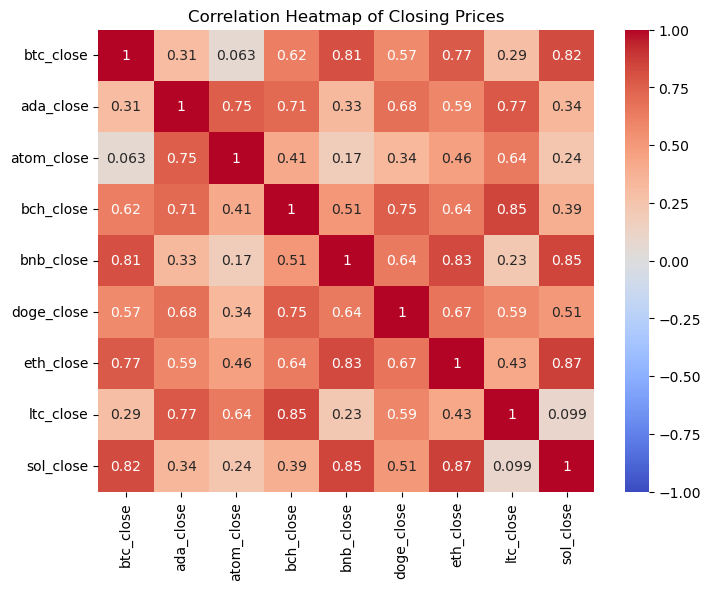

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Closing Prices")
plt.show()

# Correlation Analysis of Cryptocurrency Closing Prices

## 🔍 Overview
This section presents the correlation analysis of closing prices among nine major cryptocurrencies: BTC, ADA, ATOM, BCH, BNB, DOGE, ETH, LTC, and SOL. The correlation matrix and heatmap help identify relationships between these assets, providing insights into how they move relative to one another.

---

## 🔹 Key Observations

### 1️⃣ **Bitcoin (BTC) as a Market Driver**
- **Strong correlations** with major altcoins: **BNB (0.81), ETH (0.77), and SOL (0.82)**.
- BTC’s high correlation with these assets suggests that its price movements heavily influence the broader market.
- Lower correlation with **ATOM (0.06)**, indicating that ATOM may follow a different market dynamic.

### 2️⃣ **Ethereum (ETH) as a Bridge Asset**
- **ETH has strong correlations with BNB (0.83), SOL (0.87), and BTC (0.77)**.
- This suggests that Ethereum is closely tied to both Bitcoin and the altcoin market, often acting as a bridge between them.
- ETH also shows a moderate correlation with DOGE (0.67) and BCH (0.64), highlighting its influence across different categories of cryptocurrencies.

### 3️⃣ **BNB & SOL Show the Highest Correlation (0.85)**
- The strongest inter-altcoin relationship exists between **BNB and SOL (0.85)**, indicating that these two assets tend to move together.
- This could be attributed to their use in DeFi and exchange-based trading.

### 4️⃣ **DOGE Shows Moderate Correlation Across the Market**
- **DOGE is moderately correlated with BTC (0.57), ETH (0.67), and BNB (0.64)**.
- This suggests that while DOGE follows broader market trends, it still exhibits some level of independent price action.

### 5️⃣ **ADA and ATOM Have Lower Correlations with BTC**
- **ADA (0.31) and ATOM (0.06) show weaker correlations with BTC** compared to other assets.
- ADA, while correlated with ETH (0.59) and BCH (0.71), suggests some level of decoupling from Bitcoin.
- ATOM’s low correlation with BTC suggests it follows a more independent trajectory, possibly driven by its ecosystem growth rather than BTC market movements.

### 6️⃣ **LTC and BCH Highly Correlated**
- **LTC and BCH show a strong correlation (0.85)**, indicating that these two assets frequently move together.
- This could be due to their similar use cases as "payment-focused" cryptocurrencies.

---

## 📌 Key Takeaways
### **Market-Driven Coins: BTC, ETH, SOL, BNB**
- BTC, ETH, SOL, and BNB exhibit high correlations, reinforcing their status as dominant market movers.

### **Partially Independent Altcoins: ADA, ATOM**
- ADA and ATOM show weaker correlations with BTC, suggesting they may be influenced by ecosystem-specific factors rather than overall market sentiment.

### **Highly Correlated Pairs**
- **BNB & SOL (0.85):** Strong price synchronization.
- **LTC & BCH (0.85):** Payment-focused assets moving together.
- **ETH & SOL (0.87):** High co-movement, indicating DeFi sector correlation.

### **Investment Strategy Implications**
- **BTC and ETH-based portfolios** may experience synchronized movements, meaning they won't offer much diversification.
- **Altcoins like ADA and ATOM** can provide some diversification since they exhibit lower BTC correlations.


### 3.c Distribution Analysis

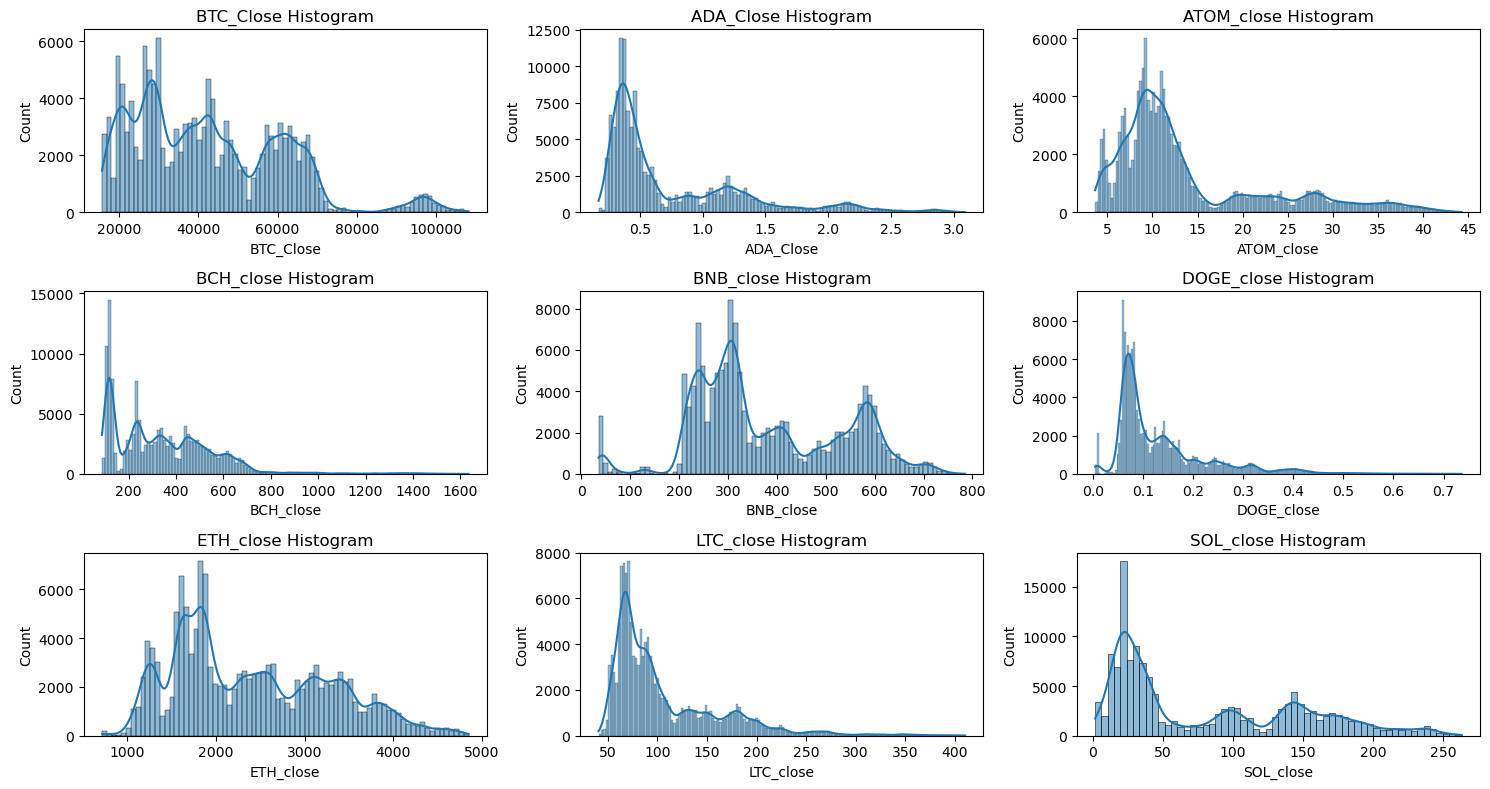

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.flatten()

df_combined = pd.DataFrame({
    'BTC_Close': df_btc['close'],
    'ADA_Close': df_ada['close'],
    'ATOM_close': df_atom['close'],
    'BCH_close': df_bch['close'],
    'BNB_close': df_bnb['close'],
    'DOGE_close': df_doge['close'],
    'ETH_close': df_eth['close'],
    'LTC_close': df_ltc['close'],
    'SOL_close': df_sol['close']
})

coins = ['BTC_Close', 'ADA_Close', 'ATOM_close', 'BCH_close', 'BNB_close', 'DOGE_close', 'ETH_close', 'LTC_close', 'SOL_close']
for i, coin in enumerate(coins):
    sns.histplot(df_combined[coin], kde=True, ax=axes[i])
    axes[i].set_title(f"{coin} Histogram")
    
plt.tight_layout()
plt.show()

# 📊 Histogram Analysis of Cryptocurrency Price Distributions

## 🔍 Overview
The histograms provide insights into the distribution of closing prices for nine major cryptocurrencies: BTC, ADA, ATOM, BCH, BNB, DOGE, ETH, LTC, and SOL. By analyzing these distributions, we can observe market cycles, price clusters, and asset-specific characteristics.

---

## 🔹 Key Observations

### **1️⃣ BTC (Bitcoin)**
- **Multi-modal distribution** with peaks at **20K-30K, 40K-50K, and 60K+**.
- This reflects different bull and bear cycles over the years.
- The right tail extends beyond **100K**, indicating price surges in recent market phases.
- Suggests strong long-term growth with multiple accumulation zones.

### **2️⃣ ADA (Cardano)**
- **Right-skewed distribution**, with most prices concentrated **below 1 USD**.
- A few price spikes above **3 USD**, indicating high volatility and occasional strong bull runs.
- The data suggests ADA had long periods of stability with sudden, sharp increases.

### **3️⃣ ATOM (Cosmos)**
- **Bimodal distribution**, with peaks around **5-10 USD** and **30-40 USD**.
- Indicates distinct phases of price accumulation and breakout movements.
- The right tail is long, suggesting a potential for high volatility.

### **4️⃣ BCH (Bitcoin Cash)**
- Shows a **left-skewed, multi-modal distribution**, with significant concentration around **100-300 USD**.
- Occasional spikes toward **1600+ USD**, suggesting periods of strong price appreciation.
- The declining volume on the right tail indicates that fewer trades occur at extreme prices.

### **5️⃣ BNB (Binance Coin)**
- Displays **a well-defined multi-modal structure**, with price clusters around **50-100, 200-400, and 600+ USD**.
- Suggests that BNB follows a strong growth pattern, aligning with its increasing adoption in DeFi and Binance Smart Chain applications.
- The wide spread indicates steady price expansion over time.

### **6️⃣ DOGE (Dogecoin)**
- **Highly skewed** with most of its price history concentrated below **0.10 USD**.
- A sharp peak at **0.7 USD** represents the **Elon Musk hype cycle of 2021**.
- Shows that DOGE has experienced **massive speculative phases**, but its base price remains relatively low.

### **7️⃣ ETH (Ethereum)**
- **Clear multi-modal structure**, with price clusters around **1K-2K, 3K-4K, and 4K+ USD**.
- This suggests that ETH has experienced several well-defined market cycles.
- Unlike BTC, ETH’s right tail is **shorter**, meaning price peaks are less extreme relative to its base values.

### **8️⃣ LTC (Litecoin)**
- Displays a **broad, bimodal distribution**, with price clusters at **50-150 USD** and **200+ USD**.
- The wide spread suggests long accumulation periods followed by strong price surges.
- Historically, LTC follows BTC movements but with lower volatility.

### **9️⃣ SOL (Solana)**
- Shows a **wide and multi-modal distribution**, with major peaks at **10-50 USD, 100 USD, and 200+ USD**.
- The spread suggests periods of rapid growth and corrections.
- A key insight is that SOL’s price expansion aligns with its increased adoption in DeFi and NFT markets.

---

## 📌 Key Takeaways

### **Market Cycles & Price Clusters**
- **Bitcoin & Ethereum exhibit multiple price clusters**, indicating long-term growth and structured accumulation phases.
- **BNB and SOL show strong multi-modal distributions**, reflecting their expansion in DeFi ecosystems.
- **DOGE and ADA have high volatility spikes**, with significant price movements driven by speculative interest.

### **Right-Skewed Distributions & Volatility**
- Most crypto assets **exhibit right-skewed distributions**, meaning they experience extended periods of lower prices with occasional bull runs.
- **DOGE, ADA, and BCH show extreme right tails**, confirming speculative surges.
- **BTC and ETH have smoother distributions**, indicating more structured market movements.

### **Investment Implications**
- **Diversified portfolios should consider assets with different distributions.** BTC and ETH provide stability, while ADA, DOGE, and SOL offer high-risk, high-reward potential.
- **Altcoins exhibit wider spreads**, meaning they tend to have greater price fluctuations compared to BTC.

### 3.e Returns‐Based Regression


===== OLS Regression: ADA vs. BTC =====
                            OLS Regression Results                            
Dep. Variable:                    ADA   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                 1.068e+05
Date:                Fri, 28 Feb 2025   Prob (F-statistic):               0.00
Time:                        17:39:42   Log-Likelihood:             5.6236e+05
No. Observations:              140181   AIC:                        -1.125e+06
Df Residuals:                  140179   BIC:                        -1.125e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

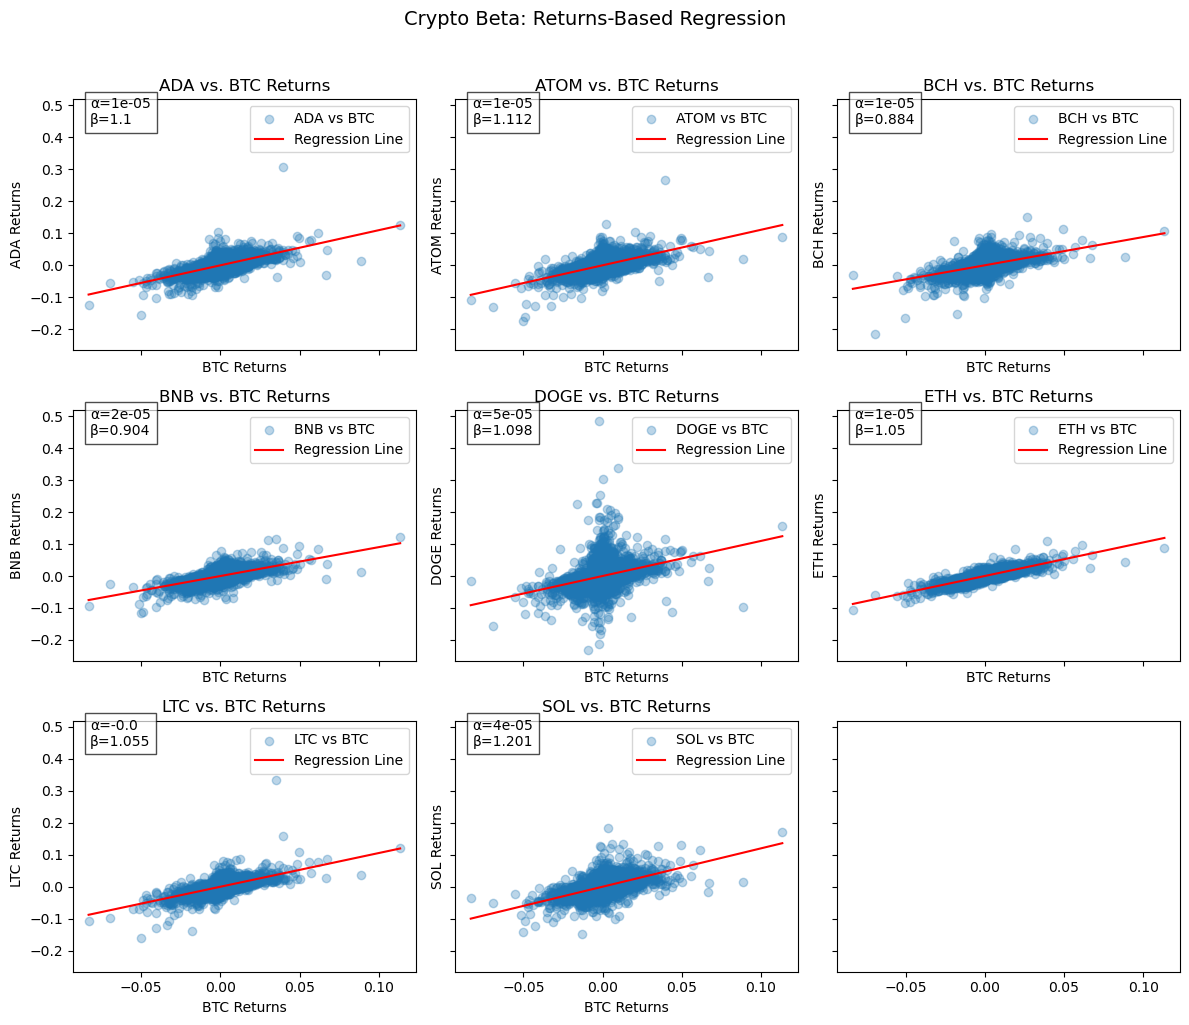

In [12]:
import statsmodels.api as sm

df_prices = pd.DataFrame({
    'BTC': df_btc.set_index('moment')['close'],
    'ADA': df_ada.set_index('moment')['close'],
    'ATOM': df_atom.set_index('moment')['close'],
    'BCH': df_bch.set_index('moment')['close'],
    'BNB': df_bnb.set_index('moment')['close'],
    'DOGE': df_doge.set_index('moment')['close'],
    'ETH': df_eth.set_index('moment')['close'],
    'LTC': df_ltc.set_index('moment')['close'],
    'SOL': df_sol.set_index('moment')['close']
}).dropna()  

df_returns = df_prices.pct_change().dropna()
alts = ['ADA', 'ATOM', 'BCH', 'BNB', 'DOGE', 'ETH', 'LTC', 'SOL']
results = {}

for alt in alts:
    X = df_returns['BTC']
    y = df_returns[alt]
    
    X = sm.add_constant(X) 
    
    model = sm.OLS(y, X).fit()
    results[alt] = model     
    print(f"\n===== OLS Regression: {alt} vs. BTC =====")
    print(model.summary())

fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten for easy iteration

for i, alt in enumerate(alts):
    ax = axes[i]
    
    X_no_const = df_returns['BTC']
    y = df_returns[alt]
    model = results[alt]
    
    ax.scatter(X_no_const, y, alpha=0.3, label=f"{alt} vs BTC")
    x_vals = np.linspace(X_no_const.min(), X_no_const.max(), 100)
    X_line = sm.add_constant(pd.Series(x_vals))  
    y_pred = model.predict(X_line)
    ax.plot(x_vals, y_pred, color='red', label="Regression Line")
    
    alpha_ = round(model.params.iloc[0], 5)  # FIXED
    beta_ = round(model.params.iloc[1], 3)   # FIXED
    ax.text(0.05, 0.9, f"α={alpha_}\nβ={beta_}", transform=ax.transAxes,
            fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    
    ax.set_title(f"{alt} vs. BTC Returns")
    ax.set_xlabel("BTC Returns")
    ax.set_ylabel(f"{alt} Returns")
    ax.legend()

plt.suptitle("Crypto Beta: Returns-Based Regression", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 📊 Regression Analysis: Altcoins vs. Bitcoin (BTC)

## 🔍 Overview
The **Ordinary Least Squares (OLS) regression** results show how closely different altcoins (ADA, ATOM, BCH, BNB, DOGE, ETH, LTC, and SOL) are related to Bitcoin (BTC). Each regression model estimates how changes in BTC prices impact the respective altcoin.

---

## 🔹 Key Regression Metrics

1. **Beta Coefficient (BTC Coefficient)**  
   - Measures how much an altcoin's price changes in response to BTC movements.
   - **Beta > 1** → Altcoin moves **more** than BTC (higher volatility).  
   - **Beta < 1** → Altcoin moves **less** than BTC (lower volatility).

2. **R-Squared (R²)**
   - Indicates the percentage of the altcoin’s price movement explained by BTC.
   - **Higher R²** → BTC has a strong influence.  
   - **Lower R²** → Other factors impact the altcoin’s price.

3. **Intercept (const)**
   - Represents the altcoin's return when BTC return is zero.
   - Close to zero suggests that BTC largely dictates price movements.

---

## 🔹 Regression Results Breakdown

### **1️⃣ ADA vs. BTC**
- **Beta = 1.0997** → ADA moves **9.97% more** than BTC.
- **R² = 0.432** → BTC explains **43.2%** of ADA’s movements.
- **Interpretation**: BTC has a **moderate influence** on ADA, but **more than half** of ADA's price changes come from independent factors.

### **2️⃣ ATOM vs. BTC**
- **Beta = 1.1117** → ATOM moves **11.17% more** than BTC.
- **R² = 0.325** → BTC explains **32.5%** of ATOM’s movements.
- **Interpretation**: ATOM exhibits **moderate BTC dependency** but has other driving forces affecting its price.

### **3️⃣ BCH vs. BTC**
- **Beta = 0.8839** → BCH moves **11.61% less** than BTC.
- **R² = 0.246** → BTC explains **24.6%** of BCH’s movements.
- **Interpretation**: BCH shows **weaker BTC correlation** and follows a **more independent price movement**.

### **4️⃣ BNB vs. BTC**
- **Beta = 0.9039** → BNB moves **9.61% less** than BTC.
- **R² = 0.439** → BTC explains **43.9%** of BNB’s movements.
- **Interpretation**: BNB is **somewhat correlated** with BTC but has significant independent influences, likely due to **Binance ecosystem** developments.

### **5️⃣ DOGE vs. BTC**
- **Beta = 1.0975** → DOGE moves **9.75% more** than BTC.
- **R² = 0.215** → BTC explains only **21.5%** of DOGE’s movements.
- **Interpretation**: DOGE is **highly speculative** and significantly influenced by social media, making it **less dependent** on BTC.

### **6️⃣ ETH vs. BTC**
- **Beta = 1.0505** → ETH moves **5.05% more** than BTC.
- **R² = 0.688** → BTC explains **68.8%** of ETH’s movements.
- **Interpretation**: ETH has **the strongest correlation** with BTC among all altcoins. BTC movements **strongly influence** ETH price trends.

### **7️⃣ LTC vs. BTC**
- **Beta = 1.0551** → LTC moves **5.51% more** than BTC.
- **R² = 0.447** → BTC explains **44.7%** of LTC’s movements.
- **Interpretation**: LTC closely follows BTC but still retains **some independent price movement**.

### **8️⃣ SOL vs. BTC**
- **Beta = 1.2006** → SOL moves **20.06% more** than BTC.
- **R² = 0.353** → BTC explains **35.3%** of SOL’s movements.
- **Interpretation**: SOL is **the most volatile** altcoin relative to BTC, but BTC’s **influence is weaker** compared to ETH.

---

## 📌 Key Takeaways

### **1️⃣ BTC Drives Altcoins, but Not Equally**
- **ETH is most strongly linked to BTC** (R² = **68.8%**).
- **DOGE is the least dependent on BTC** (R² = **21.5%**), driven largely by speculation.
- **SOL is the most volatile** relative to BTC (Beta = **1.20**).

### **2️⃣ Risk vs. Reward**
- Higher **Beta (SOL, ADA, ATOM)** → **Higher risk, higher reward**.
- Lower **Beta (BCH, BNB)** → **More stability, less reactivity**.

### **3️⃣ Other Factors Impact Price Movements**
- **BTC explains less than 50% of most altcoin movements**, meaning **other factors like ecosystem developments, news, and institutional adoption** play a crucial role.

### **4️⃣ Trading Strategies**
- **High Beta coins (SOL, ADA, ATOM)** → Suitable for traders seeking **high volatility**.
- **Low Beta coins (BNB, BCH)** → Suitable for **less risky, BTC-independent** investments.
- **ETH closely follows BTC**, making it a **safe choice for BTC-driven portfolios**.


### 3.f Pearson and Spearman Correlations

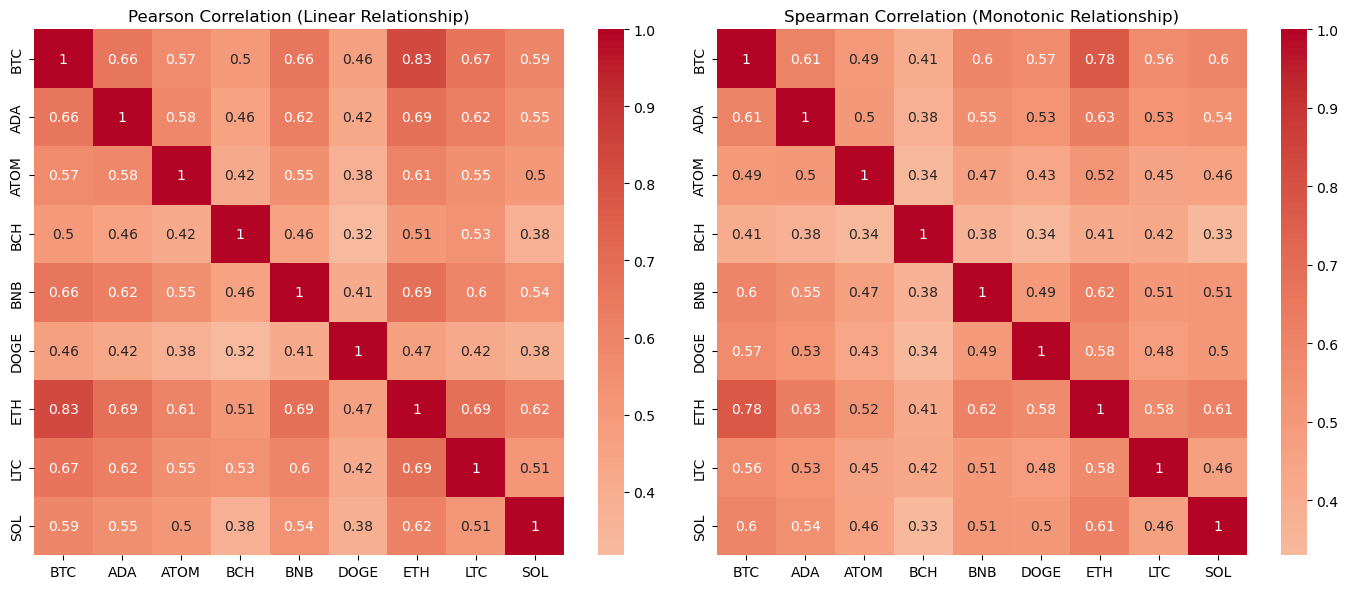


Pearson Correlation Matrix:
            BTC       ADA      ATOM       BCH       BNB      DOGE       ETH  \
BTC   1.000000  0.657589  0.570319  0.496312  0.662250  0.463380  0.829346   
ADA   0.657589  1.000000  0.583628  0.457946  0.616237  0.424911  0.686593   
ATOM  0.570319  0.583628  1.000000  0.420705  0.553662  0.377443  0.608289   
BCH   0.496312  0.457946  0.420705  1.000000  0.457536  0.317419  0.507006   
BNB   0.662250  0.616237  0.553662  0.457536  1.000000  0.409548  0.686098   
DOGE  0.463380  0.424911  0.377443  0.317419  0.409548  1.000000  0.467517   
ETH   0.829346  0.686593  0.608289  0.507006  0.686098  0.467517  1.000000   
LTC   0.668285  0.621635  0.550900  0.533125  0.598500  0.422609  0.687762   
SOL   0.594409  0.548841  0.502740  0.380578  0.537893  0.384938  0.615014   

           LTC       SOL  
BTC   0.668285  0.594409  
ADA   0.621635  0.548841  
ATOM  0.550900  0.502740  
BCH   0.533125  0.380578  
BNB   0.598500  0.537893  
DOGE  0.422609  0.384938  


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df_prices = pd.DataFrame({
    'BTC': df_btc.set_index('moment')['close'],
    'ADA': df_ada.set_index('moment')['close'],
    'ATOM': df_atom.set_index('moment')['close'],
    'BCH': df_bch.set_index('moment')['close'],
    'BNB': df_bnb.set_index('moment')['close'],
    'DOGE': df_doge.set_index('moment')['close'],
    'ETH': df_eth.set_index('moment')['close'],
    'LTC': df_ltc.set_index('moment')['close'],
    'SOL': df_sol.set_index('moment')['close']
}).dropna()

df_returns = df_prices.pct_change().dropna()

pearson_corr = df_returns.corr(method='pearson')
spearman_corr = df_returns.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pearson Heatmap
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Pearson Correlation (Linear Relationship)")

# Spearman Heatmap
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman Correlation (Monotonic Relationship)")

plt.tight_layout()
plt.show()

print("\nPearson Correlation Matrix:\n", pearson_corr)
print("\nSpearman Correlation Matrix:\n", spearman_corr)

# **Interpretation of Pearson and Spearman Correlation Matrices**

## **1️⃣ Pearson Correlation (Linear Relationship)**
Pearson correlation measures **the strength and direction of linear relationships** between cryptocurrencies.

- **Strongest Correlations with BTC:**  
  - **ETH (0.83), LTC (0.67), BNB (0.66), ADA (0.66), and SOL (0.59)**  
  - These coins exhibit a strong positive linear correlation with Bitcoin, meaning when BTC moves up or down, they tend to move similarly in **both magnitude and direction**.

- **Moderate Correlations with BTC:**  
  - **ATOM (0.57), BCH (0.50), DOGE (0.46)**  
  - These assets are influenced by BTC, but their price movements are not strictly linear. External factors such as market sentiment or coin-specific events might be playing a role.

- **Inter-Altcoin Correlations:**  
  - **ETH-BTC (0.83)** shows Ethereum's strong dependence on Bitcoin.  
  - **LTC-ETH (0.69), LTC-BNB (0.60), and BNB-ETH (0.69)** suggest that these major altcoins often move together.  
  - **DOGE has weaker correlations with most assets (~0.40-0.50),** indicating it might have more independent price behavior.

### 📌 **Key Takeaways:**
- BTC heavily drives **ETH, BNB, SOL, and LTC** movements.
- ATOM and BCH exhibit weaker correlation with BTC, indicating more independent price behavior.
- DOGE shows the weakest correlation with BTC, suggesting **more speculative and retail-driven movements**.

---

## **2️⃣ Spearman Correlation (Monotonic Relationship)**
Spearman correlation measures **whether the rank order of prices moves in the same direction**, even if the relationship isn't perfectly linear.

- **Strongest Rank-Based Correlations with BTC:**  
  - **ETH (0.78), LTC (0.56), BNB (0.60), SOL (0.60), ADA (0.61)**  
  - These altcoins tend to move in the same general direction as BTC, even if their exact price changes are not proportional.

- **Lower Spearman Correlations Compared to Pearson:**  
  - The Spearman values for **BCH (0.41), ATOM (0.49), DOGE (0.57)** are lower than Pearson, suggesting that while they move with BTC, their ranking behavior is less consistent.

- **Key Differences Between Pearson & Spearman:**  
  - Pearson values are generally higher, meaning **linear price relationships are stronger than rank-based relationships**.
  - **Spearman values for ADA, ATOM, and BCH are noticeably lower**, suggesting these assets might experience **non-linear price movements or sudden price jumps** rather than smooth trends.

### 📌 **Key Takeaways:**
- BTC **rank-based correlations** are weaker than its linear correlations, indicating **some altcoins might have more erratic behavior**.
- ETH remains **the most synchronized** with BTC, both in rank order and price movement.
- DOGE, BCH, and ATOM continue to show **more independent behavior**, with weaker rank-based movement alignment.

---

## **📌 Overall Conclusion**
- **BTC heavily influences ETH, BNB, LTC, and SOL**, both in **linear (Pearson) and rank-based (Spearman) relationships**.
- **DOGE, BCH, and ATOM** exhibit weaker dependencies on BTC, meaning their price moves are **less predictable** based on BTC trends.
- **Linear correlation (Pearson) is generally stronger than monotonic correlation (Spearman)**, meaning **altcoins follow BTC trends closely but not always in a smooth, predictable manner**.

### 🔍 **Implication for Trading & Portfolio Management:**  
- Traders relying on BTC movements should **focus on ETH, BNB, LTC, and SOL** since they are highly synchronized.
- Diversification into **ATOM, DOGE, or BCH** might reduce BTC-driven risks, as these assets exhibit less correlation with Bitcoin.
- The market exhibits **strong but not perfect synchrony**, suggesting that external factors, altcoin-specific news, and market structure all play a role.

---


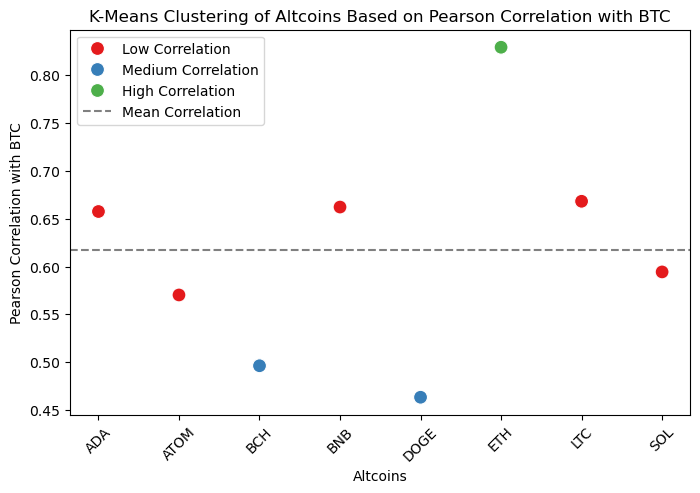

  Altcoin  Pearson_Correlation  Pearson_Correlation_Scaled  Cluster  \
0     ADA             0.657589                    0.371090        0   
1    ATOM             0.570319                   -0.441532        0   
2     BCH             0.496312                   -1.130654        1   
3     BNB             0.662250                    0.414496        0   
4    DOGE             0.463380                   -1.437303        1   
5     ETH             0.829346                    1.970427        2   
6     LTC             0.668285                    0.470691        0   
7     SOL             0.594409                   -0.217215        0   

        Cluster_Label  
0     Low Correlation  
1     Low Correlation  
2  Medium Correlation  
3     Low Correlation  
4  Medium Correlation  
5    High Correlation  
6     Low Correlation  
7     Low Correlation  


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pearson_corr = df_returns.corr()['BTC'][1:]  # Exclude BTC itself

df_corr = pd.DataFrame(pearson_corr).reset_index()
df_corr.columns = ['Altcoin', 'Pearson_Correlation']

scaler = StandardScaler()
df_corr['Pearson_Correlation_Scaled'] = scaler.fit_transform(df_corr[['Pearson_Correlation']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_corr['Cluster'] = kmeans.fit_predict(df_corr[['Pearson_Correlation_Scaled']])

df_corr['Cluster_Label'] = df_corr['Cluster'].map({0: 'Low Correlation', 1: 'Medium Correlation', 2: 'High Correlation'})

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_corr['Altcoin'], y=df_corr['Pearson_Correlation'], hue=df_corr['Cluster_Label'], palette="Set1", s=100)
plt.axhline(df_corr['Pearson_Correlation'].mean(), color='gray', linestyle='dashed', label="Mean Correlation")
plt.title("K-Means Clustering of Altcoins Based on Pearson Correlation with BTC")
plt.xlabel("Altcoins")
plt.ylabel("Pearson Correlation with BTC")
plt.legend()
plt.xticks(rotation=45)
plt.show()

print(df_corr)


# **K-Means Clustering Analysis of Altcoins Based on BTC Influence**

## **📌 Overview**
We grouped altcoins into **three clusters** using **K-Means clustering** based on their **Pearson correlation** with BTC. This categorization helps understand which altcoins move closely with BTC and which show more independent price behavior.

---

## **🔹 Cluster Assignments**

| Altcoin | Pearson Correlation | Cluster | Interpretation |
|---------|--------------------|---------|---------------|
| **ETH**  | **0.829**  | **High Correlation** | Strongly follows BTC’s price movement. |
| **BNB**  | **0.662**  | **Low Correlation**  | Shows some independence but still has a notable BTC influence. |
| **ADA**  | **0.658**  | **Low Correlation**  | Moves moderately with BTC but has independent price movements. |
| **ATOM** | **0.570**  | **Low Correlation**  | Shows lower dependency on BTC price changes. |
| **SOL**  | **0.594**  | **Low Correlation**  | Somewhat influenced by BTC but maintains its own price trends. |
| **LTC**  | **0.668**  | **Low Correlation**  | Follows BTC to a moderate extent but remains distinct. |
| **BCH**  | **0.496**  | **Medium Correlation** | Less dependent on BTC compared to other altcoins but still influenced. |
| **DOGE** | **0.463**  | **Medium Correlation** | Moves with BTC but exhibits stronger independent price swings. |

---

## **🔹 Cluster Interpretations**
### **1️⃣ High Correlation (BTC-Driven)**
- **ETH** is the only coin in this category, meaning it follows BTC’s price action the most closely.
- Investors should expect ETH to **mirror BTC’s trends** with little divergence.

### **2️⃣ Medium Correlation (Partially BTC-Influenced)**
- **BCH and DOGE** show **moderate dependency** on BTC.
- These assets are affected by BTC's trends but also have **external drivers** influencing their price.

### **3️⃣ Low Correlation (Independent Movers)**
- **ADA, ATOM, BNB, LTC, and SOL** are **less influenced by BTC** and move more independently.
- These coins could be used for **diversification** in a BTC-heavy portfolio.
- They are still correlated with BTC but not as strongly as ETH.

---

## **📌 Key Takeaways**
✅ **ETH is the most BTC-driven altcoin**, making it a highly correlated asset in the market.  
✅ **DOGE and BCH have medium correlation**, meaning they respond to BTC movements but also exhibit independent behavior.  
✅ **SOL, ADA, ATOM, BNB, and LTC** show **lower dependency on BTC**, making them **more independent investment options**.  
✅ **Diversification Strategy** → Holding a mix of **low and medium correlation assets** can help reduce BTC-driven volatility in a portfolio.

This clustering analysis provides **insightful categorization** for portfolio balancing and risk management in crypto trading! 🚀